In [79]:
import os
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import pydicom
import matplotlib.pyplot as plt
import pydicom_seg as dcmseg
from radiomics import featureextractor

In [3]:
input_dcm = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046'))
seg_dcm = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554'))
output_dicom_dir = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/nii_output'))

In [4]:
input_dcm_new = sorted(input_dcm.glob('*.dcm')) #makes list of all the paths in the directory and sorts
seg_dcm_new = sorted(seg_dcm.glob('*.dcm')) #makes list of all the paths in the directory and sorts


In [67]:
dcm = pydicom.dcmread(input_dcm_new[70]) # takes first image
sitk_img = sitk.ReadImage(input_dcm_new[70]) # reads the dicom series as a sitk image


#You should preferably use the series reader!!!
series_reader = sitk.ImageSeriesReader()
files = series_reader.GetGDCMSeriesFileNames(input_dcm)
series_reader.SetFileNames(files)
sitk_imgs = series_reader.Execute() # reads the dicom series as a sitk image

In [69]:
ct_arr = sitk.GetArrayFromImage(sitk_imgs)
print(ct_arr.shape)

(134, 512, 512)


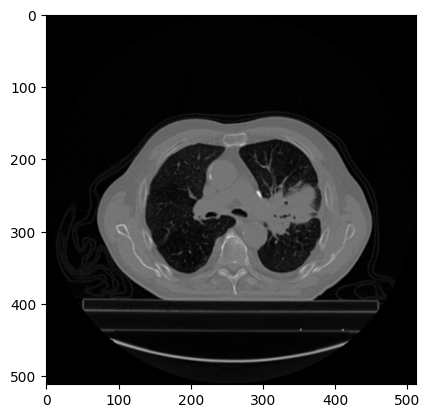

In [77]:
z = 80 # this is the slice number

arr = sitk.GetArrayFromImage(sitk_imgs)
slice = arr[z, :, :]
plt.imshow(slice, cmap='gray')
plt.show()

In [7]:
#now do the same with the segmentation dicom...

dcm_seg = pydicom.dcmread(seg_dcm_new[0])

In [ ]:
reader = dcmseg.SegmentReader()
result = reader.read(dcm_seg)
print(result.available_segments)
print(dcm_seg.SegmentSequence[0].SegmentLabel) # you need to make sure that the neoplasm label is always in the same spot!
# in this case label 1 = neoplasm, but is this always tje case?
#Are there different labels than neoplasm that correspond to the subtype of the tumour?

{1, 2, 3, 4}
Neoplasm, Primary


(134, 512, 512)
(134, 512, 512)
134


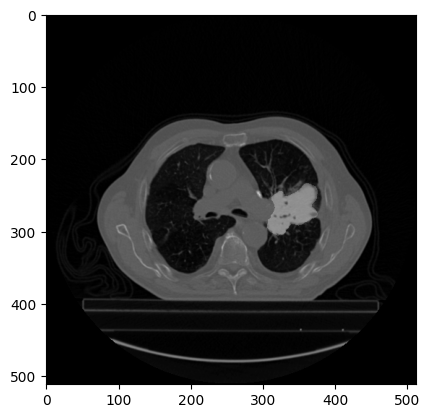

In [78]:
neoplasm_segment = result.segment_data(1) # this is the neoplasm segment, but is this always the case?
print(neoplasm_segment.shape)
neoplasm_segment_img = result.segment_image(1) # or should I do this..?
img_array_neoplasm = sitk.GetArrayFromImage(neoplasm_segment_img)
print(img_array_neoplasm.shape)
print(len(input_dcm_new))

plt.imshow(slice, cmap='gray') # overlay the original image with the segmentation mask
plt.imshow(img_array_neoplasm[80], cmap='gray', alpha=0.2) # overlay the segmentation mask with the original image
plt.show()
#something is wrong with the segmentation mask, it doesn't fit the original ct

In [54]:
print(dcm.SeriesInstanceUID)
print(dcm_seg.ReferencedSeriesSequence[0].SeriesInstanceUID)
print(dcm.GantryDetectorTilt)
print(dcm_seg.SharedFunctionalGroupsSequence[0]
      .PixelMeasuresSequence[0].PixelSpacing, dcm.PixelSpacing)
print(dcm_seg.SharedFunctionalGroupsSequence[0]
      .PixelMeasuresSequence[0].SliceThickness, dcm.SliceThickness)


1.3.6.1.4.1.32722.99.99.298991776521342375010861296712563382046
1.3.6.1.4.1.32722.99.99.298991776521342375010861296712563382046
0
[9.765625e-001, 9.765625e-001] [0.9765625, 0.9765625]
3.000000e+000 3


In [94]:
def initialize_feature_extractor():
    paramsFile = "CEM_extraction.yaml"
    extractor = featureextractor.RadiomicsFeatureExtractor(paramsFile, shape2D=True, force2D=True,
                                                               force2Ddimension=True, resampledPixelSpacing=None)
    extractor.addProvenance(False)
    extractor.disableAllFeatures()
    extractor.enableImageTypes(Original={})

    extractor.enableFeatureClassByName('firstorder', enabled=True)
    extractor.enableFeatureClassByName('shape2D', enabled=True)
    extractor.enableFeatureClassByName('glcm', enabled=True)
    extractor.enableFeatureClassByName('glrlm', enabled=True)
    extractor.enableFeatureClassByName('glszm', enabled=True)
    extractor.enableFeatureClassByName('gldm', enabled=True)
    extractor.enableFeatureClassByName('ngtdm', enabled=True)
    return extractor

In [95]:
extractor = initialize_feature_extractor()
fixed_seg = sitk.Cast(neoplasm_segment_img, sitk.sitkUInt8)
fixed_seg.CopyInformation(sitk_imgs)

In [96]:
result_extraction = extractor.execute(sitk_imgs, neoplasm_segment_img)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [93]:
input_dcm = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046'))
seg_dcm = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554'))
output_dicom_dir = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/nii_output'))
series_IDs = sitk.ImageSeriesReader.GetGDCMSeriesIDs(input_dcm)

itk_images = []
for i in range(0,len(series_IDs)):
  series_file_names = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(input_dcm, series_IDs[i])
  series_reader = sitk.ImageSeriesReader()
  series_reader.SetFileNames(series_file_names)
  series_reader.MetaDataDictionaryArrayUpdateOn()
  series_reader.LoadPrivateTagsOn()
  image_dicom = series_reader.Execute()
  
  itk_images.append(image_dicom)
  sitk.WriteImage(image_dicom, os.path.join(output_dicom_dir, series_IDs[i] + ".nii.gz"))